# The Diversity–Strength Frontier
### An honest post-mortem of Kaggle Playground S6E5 — F1 Pit-Stop Prediction

**Task:** binary classification (does a driver pit next lap?) · **Metric:** ROC-AUC · **Data:** 439,140 rows, ~80/20 imbalance

---

My best honest submission scored **0.95390**. The top of the leaderboard sat at **0.95493** — about ten basis points higher. On a synthetic tabular problem, that gap is the whole game.

The obvious assumption is that the leaders had a better model, or a feature I'd missed. So instead of guessing, I ran the experiment to its end: I tested every distinct model family I could build, measured each against the others, and watched what the ensemble actually did with them. The result was not a missing trick. It was a **frontier** — a hard, monotonic tradeoff between how *diverse* a model is and how *strong* it is, that no model on this data escapes.

This notebook is the map of that frontier.

## 1 · The climb: from the 70th percentile to the 15th

The journey up the leaderboard was driven by a handful of decisive moves, not incremental tuning. Each row is a real submission.

| Submission | OOF | LB | Percentile |
|---|---|---|---|
| LightGBM baseline | 0.94388 | 0.94432 | ~70% |
| 9-model GBDT blend | 0.95061 | 0.94993 | ~32% |
| 3-model + ORIG-concat | 0.95185 | 0.95119 | ~24% |
| RealMLP (from scratch) | 0.95356 | 0.95338 | ~18% |
| **RealMLP + XGB blend** | ~0.95470 | **0.95390** | **~15%** |

**The biggest lever wasn't a model — it was data.** The largest single jump (+13 bps) came from **ORIG-concat**: the competition data was synthesized from a real F1 strategy dataset, so I concatenated those ~101k original rows into each training fold while keeping validation on pure competition data. One ORIG-concat model beat my entire nine-model GBDT blend. *Data strategy outscored model count.*

The second jump came from blending a neural network with the trees. Tree splits and dense neural mixing make **different errors**; averaging them cancels noise. That is where the diversity question first appeared.

## 2 · Building the engine: RealMLP from components

Rather than `pip install` a tabular neural net, I reconstructed a RealMLP from its building blocks — the better to understand *why* it works. The architecture's distinctive idea is the **PBLD embedding** (Periodic Basis with Learned Decay): each numeric feature is projected through cosine waves at learned frequencies, letting the network represent periodic and threshold-like structure a plain linear layer cannot.

In [1]:
import math
import torch
import torch.nn as nn

class PBLDEmbedding(nn.Module):
    """Periodic Basis with Learned Decay: the heart of RealMLP.
    Each numeric feature -> cosine waves at learned frequencies,
    then a small learned transform. Captures thresholds & periodicity."""
    def __init__(self, n_ens, n_features, hidden_dim=20, out_dim=5,
                 freq_scale=5.0, activation=nn.PReLU):
        super().__init__()
        self.w1 = nn.Parameter(torch.randn(n_ens, n_features, hidden_dim) * freq_scale)
        self.b1 = nn.Parameter(torch.randn(n_ens, n_features, hidden_dim))
        self.w2 = nn.Parameter(torch.randn(n_ens, n_features, hidden_dim, out_dim-1)
                               / math.sqrt(hidden_dim))
        self.b2 = nn.Parameter(torch.randn(n_ens, n_features, out_dim-1))
        self.act = activation()
        nn.init.uniform_(self.b1, -math.pi, math.pi)

    def forward(self, x):
        per = torch.cos(2*math.pi*(x.unsqueeze(-1)*self.w1.unsqueeze(0) + self.b1.unsqueeze(0)))
        tr  = self.act(torch.einsum('bkfh,kfhd->bkfd', per, self.w2) + self.b2.unsqueeze(0))
        return torch.cat([x.unsqueeze(-1), tr], dim=-1).flatten(start_dim=2)

Other components mattered, and each taught something:

- **A 16-member internal ensemble** averaged at inference, batched with `einsum` rather than a Python loop.
- **Scheduled everything** — learning rate (flat-then-cosine), dropout (`expm4t` decay), and label smoothing all follow schedules that must *complete* where the model peaks. Stretching them over too many epochs scored **worse** (0.95256 at 8 epochs vs 0.95356 at 5) because they peaked mid-training.
- **Multi-seed averaging** reliably bought +5 bps by cutting neural variance.

> **Counter-intuitive finding:** more training was worse. The five-epoch model beat the eight-epoch model because its schedules finished exactly where the model converged. Schedule length is a hyperparameter, not an afterthought.

## 3 · The combiner: stacking ties blending, every time

With a pool of strong models, the natural next move is a meta-model — stacking — to learn the optimal combination. I built it properly: logit-space meta-features (turning bounded probabilities into unbounded log-odds, plus per-row summary stats), then a cross-validated logistic-regression meta-learner sweeping regularization strength.

In [2]:
import numpy as np

def logit(p, eps=1e-6):
    p = np.clip(p, eps, 1 - eps)
    return np.log(p / (1 - p))            # bounded prob -> unbounded log-odds

def build_meta_features(P):
    """P: (n_rows, n_models) matrix of base predictions."""
    L = logit(P)
    return np.hstack([
        L,
        L.mean(1, keepdims=True), L.std(1, keepdims=True),
        L.min(1, keepdims=True),  L.max(1, keepdims=True),
        (L.max(1, keepdims=True) - L.min(1, keepdims=True)),
    ])

The result, found **four separate times** across different model pools: stacking ties a simple rank-blend, to within 0.1 bp. In the five-model run, the regularization sweep landed every setting from C=0.01 to C=3.0 at the identical 0.95436–0.95437.

> *When one model dominates and the bases are correlated, a smarter combiner has nothing to exploit. The meta-model just rediscovers the blend.*

This is the first appearance of the wall. The combiner can't add what the models don't independently contain — which raises the real question: **how independent are they?**

## 4 · The finding: the diversity–strength frontier

To break a correlated ensemble, you need a model that is both **strong** (high solo accuracy) and **diverse** (low correlation to the pool). I tested nine families looking for that combination. Here is every one, plotted — strength against correlation.

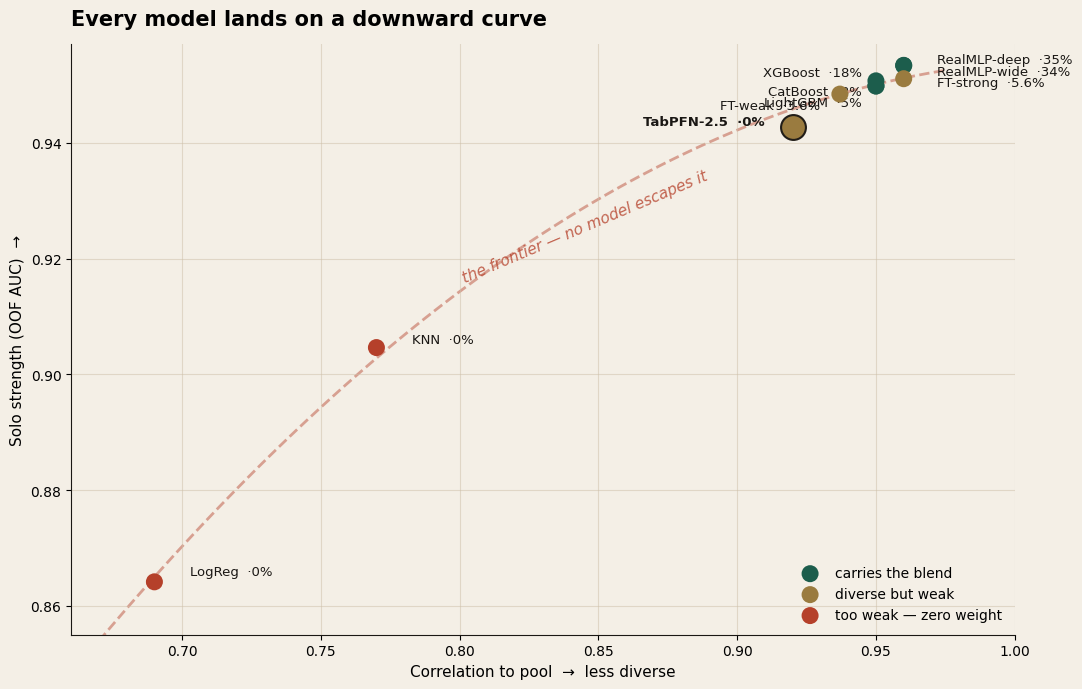

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# (model, correlation-to-pool, solo OOF AUC, blend weight %, category)
models = [
    ('RealMLP-deep', 0.96,  0.95339, 35,  'carry'),
    ('RealMLP-wide', 0.96,  0.95335, 34,  'carry'),
    ('XGBoost',      0.95,  0.95071, 18,  'carry'),
    ('CatBoost',     0.95,  0.94984, 8,   'carry'),
    ('LightGBM',     0.95,  0.94981, 5,   'carry'),
    ('FT-strong',    0.96,  0.95108, 5.6, 'tradeoff'),
    ('FT-weak',      0.937, 0.94842, 3.6, 'tradeoff'),
    ('TabPFN-2.5',   0.92,  0.94272, 0,   'tradeoff'),
    ('KNN',          0.77,  0.90462, 0,   'weak'),
    ('LogReg',       0.69,  0.86414, 0,   'weak'),
]
colors = {'carry':'#1c5d4c', 'tradeoff':'#9a7b3f', 'weak':'#b5402a'}
labels = {'carry':'carries the blend', 'tradeoff':'diverse but weak',
          'weak':'too weak \u2014 zero weight'}

# explicit label placement (x, y, ha) to avoid overlap in the dense top-right cluster
lab_pos = {
    'RealMLP-deep': (0.972, 0.95440, 'left'),
    'RealMLP-wide': (0.972, 0.95230, 'left'),
    'FT-strong':    (0.972, 0.95040, 'left'),
    'XGBoost':      (0.945, 0.95210, 'right'),
    'CatBoost':     (0.945, 0.94880, 'right'),
    'LightGBM':     (0.945, 0.94700, 'right'),
    'FT-weak':      (0.930, 0.94640, 'right'),
    'TabPFN-2.5':   (0.910, 0.94360, 'right'),
    'KNN':          (0.783, 0.90600, 'left'),
    'LogReg':       (0.703, 0.86600, 'left'),
}

fig, ax = plt.subplots(figsize=(11, 7))
fig.patch.set_facecolor('#f4efe6'); ax.set_facecolor('#f4efe6')

seen = set()
for nm, c, v, w, cat in models:
    lbl = labels[cat] if cat not in seen else None
    seen.add(cat)
    size = 320 if nm == 'TabPFN-2.5' else 150
    edge = '#211d18' if nm == 'TabPFN-2.5' else 'none'
    ax.scatter(c, v, s=size, c=colors[cat], edgecolors=edge, linewidths=1.5,
               zorder=3, label=lbl)
    lx, ly, ha = lab_pos[nm]
    ax.annotate(f'{nm}  \u00b7{w}%', (c, v), xytext=(lx, ly),
                ha=ha, va='center', fontsize=9.5, color='#1a1714',
                fontweight='bold' if nm == 'TabPFN-2.5' else 'normal')

# trend line (the frontier)
xs = np.array([0.69, 0.77, 0.92, 0.937, 0.95, 0.96])
ys = np.array([0.86414, 0.90462, 0.94272, 0.94842, 0.95040, 0.95300])
z = np.polyfit(xs, ys, 2); xf = np.linspace(0.67, 0.975, 100)
ax.plot(xf, np.polyval(z, xf), '--', color='#b5402a', alpha=0.45, lw=2, zorder=1)
ax.text(0.80, 0.916, 'the frontier \u2014 no model escapes it', rotation=23,
        color='#b5402a', fontsize=11, style='italic', alpha=0.8)

ax.set_xlabel('Correlation to pool  \u2192  less diverse', fontsize=11)
ax.set_ylabel('Solo strength (OOF AUC)  \u2192', fontsize=11)
ax.set_title('Every model lands on a downward curve',
             fontsize=15, fontweight='bold', pad=14, loc='left')
ax.grid(True, color='#cdbfa7', alpha=0.5, zorder=0)
ax.spines[['top','right']].set_visible(False)
for s in ['bottom','left']: ax.spines[s].set_color('#1a1714')
ax.legend(loc='lower right', frameon=False, fontsize=10)
ax.set_xlim(0.66, 1.00); ax.set_ylim(0.855, 0.957)
plt.tight_layout(); plt.show()

The pattern is monotonic and admits no exception: **as a model becomes more diverse, it becomes weaker.** The strong models (RealMLP, XGB) are tightly correlated at ~0.96 and carry the blend. Everything genuinely decorrelated — KNN, LogReg, and the foundation model — is too weak to earn any weight.

There is no point in the strong-and-diverse corner, because the signal in this data is **unimodal**: every capable model converges on the same predictive structure.

| Model | Solo OOF | Min corr | Blend wt | Verdict |
|---|---|---|---|---|
| RealMLP-deep | 0.95339 | 0.96 | 35% | carries |
| RealMLP-wide | 0.95335 | 0.96 | 34% | carries |
| XGBoost | 0.95071 | 0.95 | 18% | carries |
| CatBoost | 0.94984 | 0.95 | 8% | carries |
| LightGBM | 0.94981 | 0.95 | 5% | carries |
| FT-Transformer (strong) | 0.95108 | 0.96 | 5.6% | strong → correlated |
| FT-Transformer (weak) | 0.94842 | 0.937 | 3.6% | diverse, weak |
| **TabPFN-2.5** | 0.94272 | **0.92** | **0%** | most diverse, too weak |
| KNN | 0.90462 | 0.77 | 0% | far too weak |
| Logistic Regression | 0.86414 | 0.69 | 0% | weakest |

## 5 · The keystone: a foundation model stress-tests the wall

TabPFN-2.5 was the single best theoretical shot at breaking the frontier. It's a transformer **pre-trained on millions of synthetic tabular datasets** — it classifies by in-context learning, with an inductive bias shaped by pre-training rather than by what it can extract from this one dataset. If anything could sit in the strong-and-diverse corner, it was this.

It delivered exactly the diversity its pre-training promised — and the frontier held anyway:

| | value |
|---|---|
| Correlation to RealMLP | **0.92** — a record low |
| Solo OOF AUC | 0.943 — too weak |
| Blend weight assigned | **0%** |

The most diverse model in the entire investigation earned **zero weight**. At ~11 bps below the RealMLPs, the blend optimizer decided even genuinely orthogonal information wasn't worth a single percent when it arrived that weak. *(A practical note: at full scale, test inference on 188k rows projected to 43 hours — TabPFN's O(context × query) cost forced a subsampling compromise that further capped its strength. Part of the weakness is the model; part is the data scale.)*

> **Why this is the keystone:** the strongest available tool for *producing* diversity produced record diversity — and the frontier held. That's not a null result. It's the cleanest possible confirmation that the tradeoff is structural, not a failure of effort.

## 6 · What didn't work — the negative results are the point

A rigorous investigation reports its failures with the same precision as its wins. Each of these was a genuine hypothesis, tested with honest cross-validation and leak-free discipline.

**Direct Driver / Race target encoding — −7.8 bps.** A high-scoring public notebook leaned heavily on target-encoding the high-cardinality Driver and Race columns. Rebuilt *leak-free* (encoding fit inside each fold only), it made XGBoost slightly **worse** — the signal was redundant with what ORIG-concat and the combo encodings already captured. The public notebook's score came from a target leak that produced a fake 1.0 OOF AUC, not from the technique.

**The "neighbor pit" feature — not reconstructable.** A peer-reviewed paper on real F1 telemetry showed that a driver's pit probability roughly doubles when the car directly ahead pits — the classic undercut/overcut dynamic. A genuinely promising domain feature. But a feasibility check revealed the synthetic data destroyed the structure needed to build it: 96% of race-lap snapshots had duplicate track positions (61 cars sharing ~18 distinct positions), so "the car directly ahead" was ambiguous. Forced in anyway, it cost −14 bps — noise, exactly as predicted.

> **Discipline:** every tempting lever above came from a source that *looked* authoritative — a top public notebook, an academic paper. Testing them honestly, rather than trusting the source, is what kept the solution validated.

## 7 · The gap, explained

If no model breaks the frontier, where do the top scores come from? I dissected four high-scoring public solutions:

- **A 0.9544 LightGBM** — a target leak. Leave-one-out encoding computed on the full train set before CV produced a fake OOF AUC of 1.00000.
- **A 0.95452 "blend of blends"** — arithmetic combinations of 27 finished submission files, 21 downloaded from other competitors. Public-leaderboard overfitting via "rank-remap" and "micro-intervention" tricks that did nothing measurable.
- **A 0.9544 two-layer stack** — stacked other people's published OOF files. The elaborate stacking did nothing over a simple average; the lift came entirely from a larger pool of *others'* models.
- **A 0.95454 submission** — its own model was an XGBoost *regressor* on a ranking metric with 935 one-hot features and feature code referencing columns that don't exist in this dataset. The score came from a downloaded submission blended at weight 2.9 against the author's own model at weight 0.000001.

> *The gap between an honest 0.95390 and the public 0.9545s is not a skill gap. It's the difference between a self-built, validated solution and a pool of borrowed public outputs.*

This matters beyond etiquette. Pooled, public-LB-tuned solutions frequently **compress on the private leaderboard** when the hidden test split rewards genuine generalization over noise-fitting. A clean, well-validated 0.95390 is the kind of solution that *holds*.

## 8 · Transferable lessons

1. **Find the data lever first.** ORIG-concat (+13 bps) beat every modeling decision. A single well-fed model outscored a nine-model committee.
2. **Diversity is cross-family, and it's strong-vs-weak.** Neural-vs-tree is the real axis; a second model of the same family adds almost nothing.
3. **Stacking only beats blending when the bases are genuinely decorrelated.** When one model dominates a correlated pool, the meta-model just rediscovers the average. Confirmed four times.
4. **Schedules must complete where the model peaks.** Five epochs beat eight.
5. **Architecture variation beats seed variation** for cheap neural diversity (wide vs deep RealMLP correlated 0.96; same-arch seeds, 0.99+).
6. **Trust validation over sources.** Every leaked or borrowed "lever" came dressed as authority. Honest in-fold testing is the only defense.
7. **The diversity–strength tradeoff is real and may be intrinsic to a dataset.** Sometimes the ceiling is the data's, not yours — and proving that is itself a result.

---

### The ceiling was real. Mapping it was the work.

Final validated submissions: a RealMLP + XGBoost rank-blend at **0.95390**, with a multi-seed RealMLP at 0.95357 as a robust fallback. A top-15% finish — every component built, understood, and validated from scratch.

*Nine model families · two from-scratch neural architectures · one foundation model · zero borrowed submissions.*

*If this was useful, an upvote is appreciated — and I'm glad to answer questions in the comments.*